# Regresión Lineal Multivariable
## Aplicado al Conjunto de Datos de Contaminación del Aire (2000-2021)

**Objetivo:** Predecir el Índice de Calidad del Aire del Ozono (O3 AQI) a partir de dos características:
- **X₁** = Promedio de Ozono (O3 Mean) — promedio diario de concentración de ozono
- **X₂** = Valor Máximo de Ozono (O3 1st Max Value) — valor máximo diario de ozono
- **y** = Índice de Calidad del Aire del Ozono (O3 AQI) — lo que queremos predecir

In [1]:
import numpy as np
from matplotlib import pyplot

In [2]:
# Leer datos del conjunto de datos de contaminación del aire
# usecols selecciona solo las columnas numéricas que necesitamos:
#   columna 8 = O3 Promedio, columna 9 = O3 Valor Maximo, columna 11 = O3 ICA
# genfromtxt convierte valores con formato malo a NaN automáticamente
data = np.genfromtxt('contaminacion_2000_2021.csv', delimiter=';',
                     skip_header=1, usecols=(8, 9, 11),
                     encoding='utf-8', invalid_raise=False)

# Eliminar filas con NaN (valores que no se pudieron convertir a número)
data = data[~np.isnan(data).any(axis=1)]

X, y = data[:, :2], data[:, 2]
m = y.size

print(f'Número de ejemplos de entrenamiento (m): {m}')
print()
print('Primeras 5 filas de X:')
print(X[:5])
print()
print(f'Forma de X: {X.shape}')

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_17556\1737965188.py:5: ConversionWarning: Some errors were detected !
    Line #7056 (got 5 columns instead of 3)
    Line #7057 (got 5 columns instead of 3)
    Line #7058 (got 5 columns instead of 3)
    Line #7059 (got 5 columns instead of 3)
    Line #7060 (got 5 columns instead of 3)
    Line #7061 (got 5 columns instead of 3)
    Line #7062 (got 5 columns instead of 3)
    Line #7063 (got 5 columns instead of 3)
    Line #7064 (got 5 columns instead of 3)
    Line #7065 (got 5 columns instead of 3)
    Line #7066 (got 5 columns instead of 3)
    Line #7067 (got 5 columns instead of 3)
    Line #7068 (got 5 columns instead of 3)
    Line #7069 (got 5 columns instead of 3)
    Line #7070 (got 5 columns instead of 3)
    Line #7071 (got 5 columns instead of 3)
    Line #7072 (got 5 columns instead of 3)
    Line #7073 (got 5 columns instead of 3)
    Line #7074 (got 5 columns instead of 3)
    Line #7075 (got 5 columns instead of 3)
    L

Número de ejemplos de entrenamiento (m): 590739

Primeras 5 filas de X:
[[0.019765 0.04    ]
 [0.015882 0.032   ]
 [0.009353 0.016   ]
 [0.015882 0.033   ]
 [0.007353 0.012   ]]

Forma de X: (590739, 2)


## Normalización de características

### Fórmula:  $X_{norm} = \frac{X - \mu}{\sigma}$

Donde $\mu$ es la media y $\sigma$ la desviación estándar de cada característica.
Esto hace que las características tengan escala similar para que el descenso de gradiente converja más rápido.

In [3]:
def normalizarCaracteristicas(X):
    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis = 0)
    sigma = np.std(X, axis = 0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [4]:
# Llamar normalizarCaracteristicas con los datos cargados
X_norm, mu, sigma = normalizarCaracteristicas(X)

print(X)
print('Media calculada:', mu)
print('Desviación estandar calculada:', sigma)
print(X_norm)

[[0.019765 0.04    ]
 [0.015882 0.032   ]
 [0.009353 0.016   ]
 ...
 [0.039765 0.05    ]
 [0.049176 0.058   ]
 [0.052333 0.054   ]]
Media calculada: [0.02838197 0.03889496]
Desviación estandar calculada: [0.01214919 0.015028  ]
[[-0.70926303  0.07353228]
 [-1.02887283 -0.45880739]
 [-1.56627495 -1.52348673]
 ...
 [ 0.93693735  0.73895686]
 [ 1.71155693  1.27129653]
 [ 1.97140966  1.0051267 ]]


## Visualización de los datos

Graficamos las relaciones entre las características y la variable objetivo para entender los datos.

In [5]:
def graficarDatos(x, y, xlabel, ylabel):
  fig = pyplot.figure()
  pyplot.plot(x, y, 'ro', markersize=2, alpha=0.3)
  pyplot.xlabel(xlabel)
  pyplot.ylabel(ylabel)

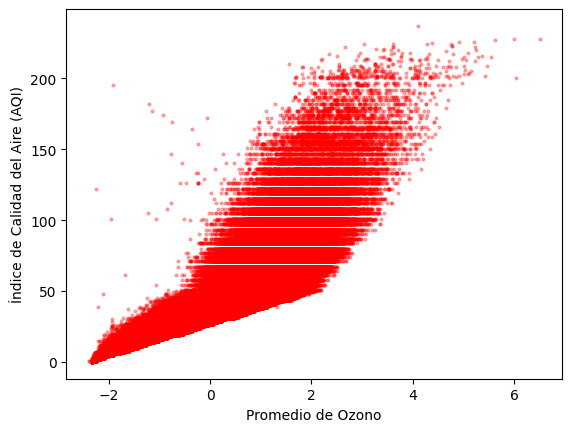

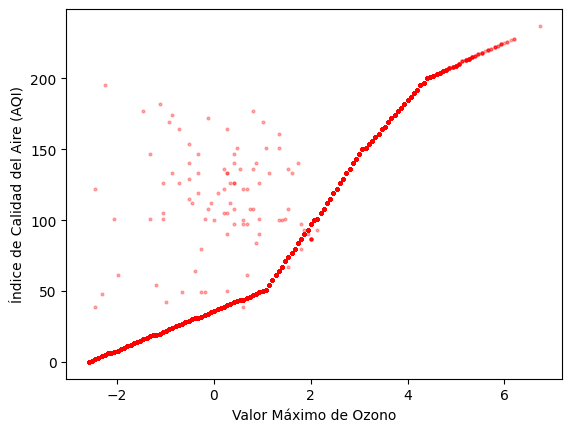

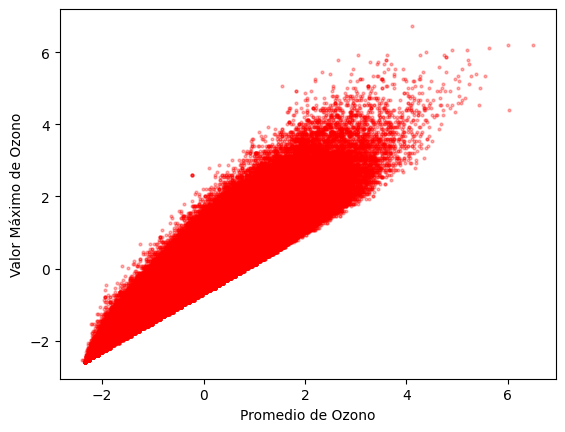

In [6]:
xlabel1 = "Promedio de Ozono"
xlabel2 = "Valor Máximo de Ozono"
ylabel1 = "Índice de Calidad del Aire (AQI)"

graficarDatos(X_norm[:, 0], y, xlabel1, ylabel1)
graficarDatos(X_norm[:, 1], y, xlabel2, ylabel1)
graficarDatos(X_norm[:, 0], X_norm[:, 1], xlabel1, xlabel2)

## Agregar columna de unos a la matriz X

Se agrega una columna de 1s al inicio para que el modelo aprenda el término independiente ($\theta_0$).

### Hipótesis: $h_\theta(x) = \theta_0 \cdot 1 + \theta_1 \cdot x_1 + \theta_2 \cdot x_2$

En forma matricial: $h_\theta(X) = X \cdot \theta$

In [7]:
# No olvidarse agregar unos a la matriz de X normalizada
X_ready = np.concatenate([np.ones((m, 1)), X_norm], axis=1)
X_ready

array([[ 1.        , -0.70926303,  0.07353228],
       [ 1.        , -1.02887283, -0.45880739],
       [ 1.        , -1.56627495, -1.52348673],
       ...,
       [ 1.        ,  0.93693735,  0.73895686],
       [ 1.        ,  1.71155693,  1.27129653],
       [ 1.        ,  1.97140966,  1.0051267 ]], shape=(590739, 3))

## Función de Costo J(θ) — Error Cuadrático Medio

Mide qué tan lejos están las predicciones de los valores reales. Queremos minimizar este valor.

### Fórmula: $J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right)^2$

Donde $h_\theta(x) = X \cdot \theta$ son las predicciones y $y$ los valores reales.

In [8]:
def calcularCosto(X, y, theta):
  m = y.size
  J = 0
  J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))
  return J

In [9]:
# Probar la función de costo con un valor de theta de prueba
theta = np.array([0.1, 5.0, 0.1])
JJ = calcularCosto(X_ready, y, theta)
print(f"con theta:{ theta } se obtiene un costo de: {JJ}")

con theta:[0.1 5.  0.1] se obtiene un costo de: 935.440762356381


## Descenso de Gradiente

Algoritmo iterativo que ajusta los parámetros $\theta$ para minimizar la función de costo $J(\theta)$.

### Fórmula de actualización:

$$\theta_j := \theta_j - \alpha \cdot \frac{1}{m} \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right) \cdot x_j^{(i)}$$

En forma vectorizada: $\theta := \theta - \frac{\alpha}{m} \cdot (X\theta - y) \cdot X$

Donde $\alpha$ es la tasa de aprendizaje (controla qué tan grande es cada paso de actualización).

In [10]:
def calcularDescensoGradiente(X, y, theta, alpha, numero_iteraciones):
  m = y.shape[0]
  theta = theta.copy()
  J_historico = []

  for i in range(numero_iteraciones):
    theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
    J_historico.append(calcularCosto(X, y, theta))

  return theta, J_historico

## Entrenar el modelo y graficar la convergencia

Ejecutamos el descenso de gradiente y observamos cómo el costo $J$ va disminuyendo con cada iteración.

los valores de theta calculados son: [39.11252591 -0.80200495 21.3468466 ]
con un costo de: 33.718908377002045 


Text(0, 0.5, 'Costo J')

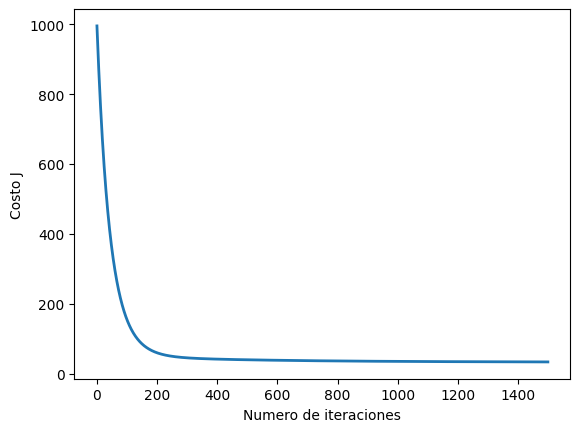

In [11]:
theta = np.zeros(3)

# Con datos normalizados y un conjunto de datos grande (600K+ filas),
# alpha=0.01 y 1500 iteraciones es suficiente para converger
num_ite = 1500
alpha = 0.01

theta, J_historico = calcularDescensoGradiente(X_ready, y, theta, alpha, num_ite)
print(f"los valores de theta calculados son: { theta }")
print(f"con un costo de: { J_historico[-1]} ")

# Graficar la convergencia del costo
pyplot.plot(np.arange(len(J_historico)), J_historico, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')

## Graficar los datos de entrenamiento con la línea de regresión

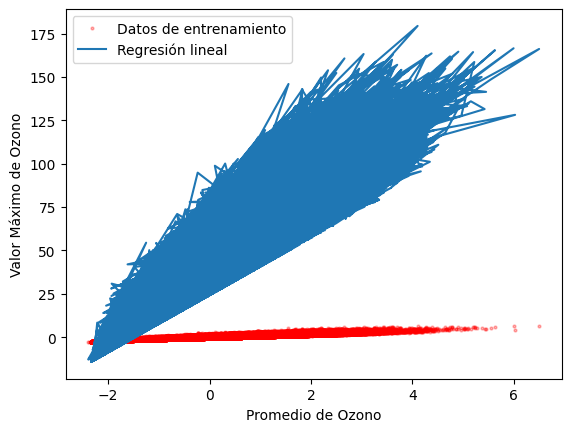

In [12]:
graficarDatos(X_ready[:, 1], X_ready[:, 2], xlabel1, xlabel2)

pyplot.plot(X_ready[:, 1], np.dot(X_ready, theta), '-')

pyplot.legend(['Datos de entrenamiento', 'Regresión lineal'])

## Predicción con valores nuevos

Para predecir con datos nuevos hay que normalizarlos con la misma media y desviación estándar del entrenamiento.

### Fórmula: $\hat{y} = \theta^T \cdot x_{nuevo}$

In [13]:
# Predecir el AQI para un día con Promedio de Ozono = 0.04 y Valor Máximo de Ozono = 0.08

# Sin normalizar (predicción directa, no es correcto pero se muestra para comparar)
y_pred1 = np.dot([1, 0.04, 0.08], theta)

# Normalizado correctamente con la media y sigma del entrenamiento
xp = np.array([1, (0.04 - mu[0]) / sigma[0], (0.08 - mu[1]) / sigma[1]])
y_pred = np.dot(xp, theta)

print(y_pred1, y_pred)

40.78819344423765 96.73413297999792


## Ecuación Normal (Método Alternativo)

Calcula los parámetros theta de forma directa sin necesidad de iteraciones ni tasa de aprendizaje.

### Fórmula: $\theta = (X^T X)^{-1} X^T y$

**Ventaja:** No necesita normalizar los datos ni elegir la tasa de aprendizaje.
**Desventaja:** Es lento con conjuntos de datos muy grandes porque requiere invertir una matriz.
**Importante:** Trabaja con los datos originales (sin normalizar).

In [14]:
def calcularThetaEcuacionNormal(X, y):
    theta = np.zeros(X.shape[1])
    theta = np.dot(np.dot(np.linalg.inv(np.dot(X.T,X)),X.T),y)
    return theta

In [15]:
# Para la ecuación normal usamos los datos originales (sin normalizar)
X_ren = np.concatenate([np.ones((m, 1)), X], axis=1)
theta = calcularThetaEcuacionNormal(X_ren, y);
print(f"los valores de theta calculados son: { theta }")

los valores de theta calculados son: [ -14.906833  -276.2465583 1590.4321934]


In [ ]:
# Predicción con la ecuación normal (datos sin normalizar)
# Predecir AQI para Promedio de Ozono = 0.04 y Valor Máximo de Ozono = 0.08
X_array = [1, 0.04, 0.08]
aqi_pred = np.dot(X_array, theta)

print('AQI predicho para Promedio Ozono=0.04 y Máximo Ozono=0.08 (usando la ecuación normal): {:.2f}'.format(aqi_pred))

AQI predicho para Promedio Ozono=0.04 y Máximo Ozono=0.08 (usando la ecuación normal): 101.28
